# Phân tích cảm xúc người dùng từ đánh giá sản phẩm Shopee bằng NLP

**Mục tiêu:** Thu thập dữ liệu văn bản, sử dụng kỹ thuật NLP để trích xuất thông tin và phân tích cảm xúc người dùng.

**Công cụ:** Python (NLTK, spaCy, Transformers, Gensim)



---
## PHẦN I: XỬ LÝ DỮ LIỆU CƠ BẢN
---

## 1. Nhập thư viện (Import Libraries)

In [3]:
# Cài đặt thư viện (chạy cell này nếu môi trường chưa có thư viện)
# Lưu ý: nếu chạy trên Kaggle/Colab/Jupyter, cell này sẽ in log cài đặt và thông báo hoàn tất.

print("Bắt đầu kiểm tra/cài đặt thư viện cần thiết...")
%pip install -q nltk transformers torch underthesea imbalanced-learn gensim
print("Đã hoàn tất bước cài đặt thư viện. Nếu không có lỗi màu đỏ, có thể chạy cell tiếp theo.")

Bắt đầu kiểm tra/cài đặt thư viện cần thiết...
^C
Note: you may need to restart the kernel to use updated packages.
Đã hoàn tất bước cài đặt thư viện. Nếu không có lỗi màu đỏ, có thể chạy cell tiếp theo.


## 2. Cài đặt các thư viện cần thiết

In [4]:
import re
import os
import glob
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    f1_score, precision_score, recall_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import label_binarize
from sklearn.base import clone

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# NLP Libraries
try:
    from underthesea import word_tokenize
    UNDERTHESEA_AVAILABLE = True
except ImportError:
    UNDERTHESEA_AVAILABLE = False

try:
    import nltk
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords as nltk_stopwords
    NLTK_AVAILABLE = True
except Exception as e:
    NLTK_AVAILABLE = False
    print(f'NLTK không khả dụng: {e}')

try:
    import spacy
    try:
        nlp = spacy.load('vi_core_news_lg')
        SPACY_AVAILABLE = True
    except Exception:
        nlp = None
        SPACY_AVAILABLE = False
except ImportError:
    nlp = None
    SPACY_AVAILABLE = False

try:
    from gensim.models import Word2Vec, FastText
    GENSIM_AVAILABLE = True
except Exception as e:
    GENSIM_AVAILABLE = False
    GENSIM_ERROR = str(e)

# Thiết lập biểu đồ
sns.set(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)

def show_title(title):
    print("\n" + "="*90)
    print(title)
    print("="*90)

def display_df(title, data, max_rows=10):
    # In tiêu đề tiếng Việt và hiển thị DataFrame/Series gọn gàng.
    print(f"\n{title}")
    if isinstance(data, pd.Series):
        display(data.head(max_rows).to_frame())
    elif isinstance(data, pd.DataFrame):
        display(data.head(max_rows))
    else:
        print(data)

show_title("KẾT QUẢ CELL 2: IMPORT THƯ VIỆN")
library_status = pd.DataFrame({
    "Thư viện / gói": ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "imbalanced-learn", "underthesea", "NLTK", "spaCy vi_core_news_lg", "Gensim"],
    "Trạng thái": ["OK", "OK", "OK", "OK", "OK", "OK", "OK" if UNDERTHESEA_AVAILABLE else "Không có - dùng fallback",
                   "OK" if NLTK_AVAILABLE else "Không có", "OK" if SPACY_AVAILABLE else "Không có - dùng fallback",
                   "OK" if GENSIM_AVAILABLE else "Không có - bỏ qua Word2Vec/FastText"],
})
display(library_status)
print("Đã import xong thư viện và thiết lập hàm hiển thị dữ liệu.")


KẾT QUẢ CELL 2: IMPORT THƯ VIỆN


,Thư viện / gói,Trạng thái
0,pandas,OK
1,numpy,OK
2,matplotlib,OK
3,seaborn,OK
4,scikit-learn,OK
5,imbalanced-learn,OK
6,underthesea,Không có - dùng fallback
7,NLTK,OK
8,spaCy vi_core_news_lg,Không có - dùng fallback
9,Gensim,Không có - bỏ qua Word2Vec/FastText


Đã import xong thư viện và thiết lập hàm hiển thị dữ liệu.


## 3. Tải và mô tả dữ liệu (Load & Describe Data)

In [5]:
show_title("KẾT QUẢ CELL 3: TẢI VÀ MÔ TẢ DỮ LIỆU")

candidate_paths = [
    os.path.join('..', 'FILE CSV', 'shopee_reviews_dataset.csv'),
    os.path.join('FILE CSV', 'shopee_reviews_dataset.csv'),
    'shopee_reviews_dataset.csv',
    os.path.join('/mnt/data', 'shopee_reviews_dataset.csv')
]
csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_path is None:
    matches = glob.glob('**/shopee_reviews_dataset.csv', recursive=True)
    csv_path = matches[0] if matches else None

if csv_path is None:
    raise FileNotFoundError(
        "Không tìm thấy shopee_reviews_dataset.csv. "
        "Hãy đặt file CSV cùng thư mục notebook hoặc trong thư mục FILE CSV."
    )

df = pd.read_csv(csv_path)

print(f"Đường dẫn dữ liệu: {csv_path}")
print(f"Kích thước dữ liệu: {df.shape[0]} dòng × {df.shape[1]} cột")
print(f"Danh sách cột: {list(df.columns)}")

display_df("5 dòng đầu tiên của dữ liệu gốc:", df, max_rows=5)
display_df("Kiểu dữ liệu từng cột:", df.dtypes.rename("Kiểu dữ liệu"), max_rows=20)

if {'review', 'rating', 'label'}.issubset(df.columns):
    label_rating_summary = pd.crosstab(df['label'], df['rating'], margins=True)
    display_df("Bảng chéo nhãn cảm xúc theo rating:", label_rating_summary, max_rows=20)
else:
    print("Lưu ý: dữ liệu nên có các cột review, rating, label để chạy toàn bộ notebook.")


KẾT QUẢ CELL 3: TẢI VÀ MÔ TẢ DỮ LIỆU
Đường dẫn dữ liệu: ..\FILE CSV\shopee_reviews_dataset.csv
Kích thước dữ liệu: 9599 dòng × 4 cột
Danh sách cột: ['id', 'review', 'rating', 'label']

5 dòng đầu tiên của dữ liệu gốc:


,id,review,rating,label
0,74263765409,Hương vị:thom Chắc do bên giao hàng bị vỡ mấy...,3,negative
1,11104151002,Hương thơm:nhẹ nhàng Lợi ích:phục hồi cấp ẩm M...,5,positive
2,15888299382,Chất lượng sản phẩm:ok Đúng với mô tả:đúng Lầ...,5,positive
3,81030214453,Độ tuổi sử dụng:em bes Chất lượng sản phẩm:tot...,5,positive
4,88484377297,"Hương vị:Mix vị, Tím Mình mua 64 gói (32 gói ...",1,negative



Kiểu dữ liệu từng cột:


,Kiểu dữ liệu
id,int64
review,object
rating,int64
label,object



Bảng chéo nhãn cảm xúc theo rating:


rating,1,2,3,4,5,All
label,,,,,,
negative,2958,1221,1691,29,66,5965
positive,14,9,91,67,3453,3634
All,2972,1230,1782,96,3519,9599


## 4. Kiểm tra chất lượng dữ liệu (Data Quality Checks)

In [6]:
show_title("KẾT QUẢ CELL 4: KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")

quality_summary = pd.DataFrame({
    "Chỉ số": [
        "Số dòng",
        "Số cột",
        "Review bị thiếu",
        "Rating bị thiếu",
        "Label bị thiếu",
        "Review rỗng sau strip",
        "Dòng trùng hoàn toàn",
        "Review bị trùng"
    ],
    "Giá trị": [
        len(df),
        df.shape[1],
        df["review"].isna().sum() if "review" in df.columns else np.nan,
        df["rating"].isna().sum() if "rating" in df.columns else np.nan,
        df["label"].isna().sum() if "label" in df.columns else np.nan,
        (df["review"].astype(str).str.strip() == "").sum() if "review" in df.columns else np.nan,
        df.duplicated().sum(),
        df.duplicated(subset=["review"]).sum() if "review" in df.columns else np.nan
    ]
})
display_df("Bảng kiểm tra chất lượng dữ liệu:", quality_summary, max_rows=20)

missing_by_col = df.isna().sum().sort_values(ascending=False).rename("Số giá trị thiếu")
display_df("Số giá trị thiếu theo từng cột:", missing_by_col, max_rows=20)


KẾT QUẢ CELL 4: KIỂM TRA CHẤT LƯỢNG DỮ LIỆU

Bảng kiểm tra chất lượng dữ liệu:


,Chỉ số,Giá trị
0,Số dòng,9599
1,Số cột,4
2,Review bị thiếu,0
3,Rating bị thiếu,0
4,Label bị thiếu,0
5,Review rỗng sau strip,0
6,Dòng trùng hoàn toàn,0
7,Review bị trùng,0



Số giá trị thiếu theo từng cột:


,Số giá trị thiếu
id,0
review,0
rating,0
label,0


## 5. Làm sạch và chuẩn hóa dữ liệu (Data Cleaning & Normalization)

In [7]:
show_title("KẾT QUẢ CELL 5: LÀM SẠCH VÀ CHUẨN HÓA DỮ LIỆU")

df_clean = df.copy()
df_clean['review'] = df_clean['review'].astype(str)
df_clean['label'] = df_clean['label'].astype(str)

rows_before = len(df_clean)

df_clean['label'] = df_clean['label'].str.strip().str.lower()
label_map = {'positive': 'positive', 'negative': 'negative', 'neutral': 'neutral'}
df_clean['label'] = df_clean['label'].map(label_map).fillna(df_clean['label'])

df_clean = df_clean[df_clean['review'].str.strip() != '']
df_clean = df_clean[df_clean['label'].isin(['positive', 'negative', 'neutral'])]
df_clean = df_clean.drop_duplicates(subset=['review', 'rating', 'label']).reset_index(drop=True)

rows_after = len(df_clean)

cleaning_summary = pd.DataFrame({
    "Chỉ số": ["Số dòng trước làm sạch", "Số dòng sau làm sạch", "Số dòng đã loại bỏ", "Số nhãn còn lại"],
    "Giá trị": [rows_before, rows_after, rows_before - rows_after, df_clean['label'].nunique()]
})
display_df("Tóm tắt sau làm sạch:", cleaning_summary, max_rows=10)

label_counts = df_clean['label'].value_counts().rename_axis("Nhãn").reset_index(name="Số lượng")
display_df("Phân bố nhãn sau làm sạch:", label_counts, max_rows=10)

display_df("5 dòng dữ liệu sau làm sạch:", df_clean[['review', 'rating', 'label']], max_rows=5)


KẾT QUẢ CELL 5: LÀM SẠCH VÀ CHUẨN HÓA DỮ LIỆU

Tóm tắt sau làm sạch:


,Chỉ số,Giá trị
0,Số dòng trước làm sạch,9599
1,Số dòng sau làm sạch,9599
2,Số dòng đã loại bỏ,0
3,Số nhãn còn lại,2



Phân bố nhãn sau làm sạch:


,Nhãn,Số lượng
0,negative,5965
1,positive,3634



5 dòng dữ liệu sau làm sạch:


,review,rating,label
0,Hương vị:thom Chắc do bên giao hàng bị vỡ mấy...,3,negative
1,Hương thơm:nhẹ nhàng Lợi ích:phục hồi cấp ẩm M...,5,positive
2,Chất lượng sản phẩm:ok Đúng với mô tả:đúng Lầ...,5,positive
3,Độ tuổi sử dụng:em bes Chất lượng sản phẩm:tot...,5,positive
4,"Hương vị:Mix vị, Tím Mình mua 64 gói (32 gói ...",1,negative


## 6. Khám phá dữ liệu (Exploratory Data Analysis)


KẾT QUẢ CELL 6: KHÁM PHÁ DỮ LIỆU

Thống kê độ dài review và số từ:


,count,mean,std,min,25%,50%,75%,max
review_length,9599.0,133.919575,109.318574,20.0,71.0,106.0,159.0,2021.0
word_count,9599.0,30.215335,24.969633,3.0,16.0,24.0,36.0,444.0



Dữ liệu dùng cho biểu đồ số lượng review theo nhãn:


,Nhãn cảm xúc,Số lượng
0,positive,3634
1,negative,5965



Dữ liệu dùng cho biểu đồ số lượng review theo rating:


,Rating,Số lượng
0,1,2972
1,2,1230
2,3,1782
3,4,96
4,5,3519


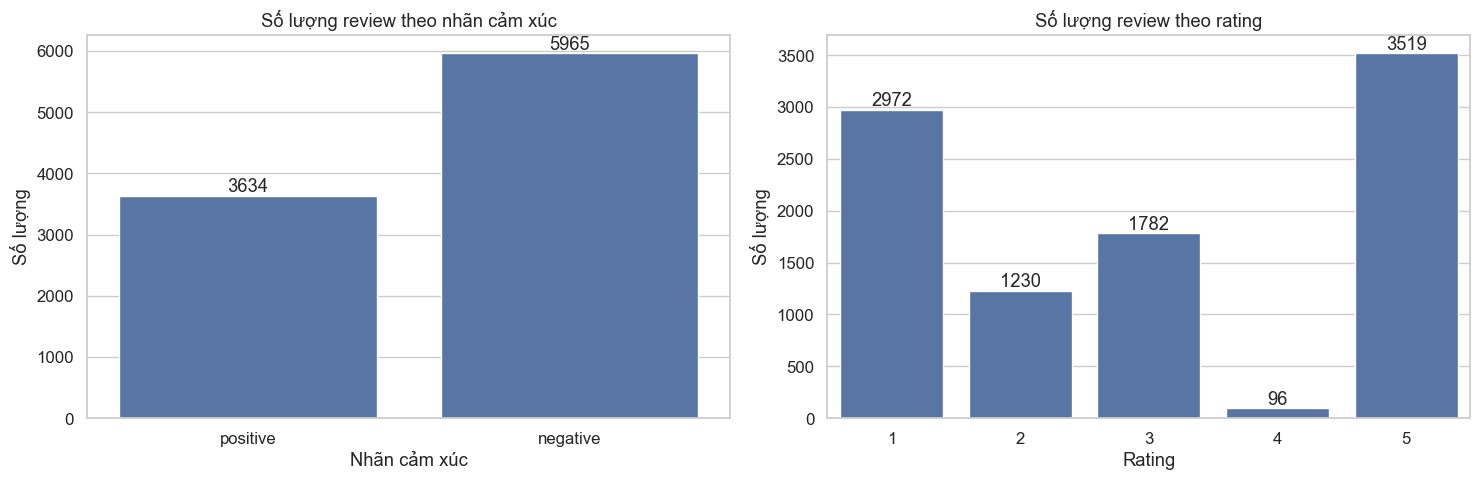

In [8]:
show_title("KẾT QUẢ CELL 6: KHÁM PHÁ DỮ LIỆU")

df_clean['review_length'] = df_clean['review'].str.len()
df_clean['word_count'] = df_clean['review'].str.split().apply(len)

stats_table = df_clean[['review_length', 'word_count']].describe().T
display_df("Thống kê độ dài review và số từ:", stats_table, max_rows=10)

label_order = [lbl for lbl in ['positive', 'neutral', 'negative'] if lbl in df_clean['label'].unique()]
rating_order = sorted(df_clean['rating'].dropna().unique())

label_count_df = df_clean['label'].value_counts().reindex(label_order).reset_index()
label_count_df.columns = ['Nhãn cảm xúc', 'Số lượng']
rating_count_df = df_clean['rating'].value_counts().sort_index().reset_index()
rating_count_df.columns = ['Rating', 'Số lượng']

display_df("Dữ liệu dùng cho biểu đồ số lượng review theo nhãn:", label_count_df, max_rows=10)
display_df("Dữ liệu dùng cho biểu đồ số lượng review theo rating:", rating_count_df, max_rows=10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=label_count_df, x='Nhãn cảm xúc', y='Số lượng', ax=axes[0])
axes[0].set_title('Số lượng review theo nhãn cảm xúc')
axes[0].set_xlabel('Nhãn cảm xúc')
axes[0].set_ylabel('Số lượng')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

sns.barplot(data=rating_count_df, x='Rating', y='Số lượng', ax=axes[1])
axes[1].set_title('Số lượng review theo rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Số lượng')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

## 7. Làm sạch văn bản (Text Cleaning)

In [9]:
show_title("KẾT QUẢ CELL 7: LÀM SẠCH VĂN BẢN")

emoji_pattern = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
url_pattern = re.compile(r'https?://\S+|www\.\S+')
special_pattern = re.compile(r'[^\w\sàáảãạâầấậẩẫăằắặẳẵèéẻẽẹêềếệểễìíỉĩịòóỏõọôồốộổỗơờớợởỡùúủũụưừứựửữỳýỷỹỵđÀÁẢÃẠÂẦẤẬẨẪĂẰẮẶẲẴÈÉẺẼẸÊỀẾỆỂỄÌÍỈĨỊÒÓỎÕỌÔỒỐỘỔỖƠỜỚỢỞỠÙÚỦŨỤƯỪỨỰỬỮỲÝỶỸỴĐ]+')

def clean_text(text):
    text = str(text).lower()
    text = url_pattern.sub(' ', text)
    text = emoji_pattern.sub(' ', text)
    text = special_pattern.sub(' ', text)
    text = re.sub(r'(\w)\1{2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_abbreviations(text):
    replacements = {
        'sp': 'sản phẩm', 'shop': 'cửa hàng', 'mn': 'mọi người',
        'ko': 'không', 'kh': 'không', 'dc': 'được', 'đc': 'được',
        'r': 'rồi', 'nt': 'như thế', 'ok': 'ổn', 'okê': 'ổn',
        'bh': 'bảo hành', 'gh': 'giao hàng', 'ship': 'giao hàng',
        'spk': 'sản phẩm', 'sl': 'số lượng', 'mng': 'mọi người'
    }
    for old, new in replacements.items():
        text = re.sub(r'\b' + re.escape(old) + r'\b', new, text)
    return text

df_clean['review_clean'] = df_clean['review'].apply(clean_text).apply(normalize_abbreviations)

sample_cleaning = df_clean[['review', 'review_clean', 'label']].head(10)
display_df("Ví dụ trước/sau khi làm sạch văn bản:", sample_cleaning, max_rows=10)

cleaning_lengths = pd.DataFrame({
    "Loại văn bản": ["Review gốc", "Review sau làm sạch"],
    "Độ dài trung bình": [df_clean['review'].str.len().mean(), df_clean['review_clean'].str.len().mean()],
    "Số từ trung bình": [df_clean['review'].str.split().apply(len).mean(), df_clean['review_clean'].str.split().apply(len).mean()]
})
display_df("So sánh độ dài trước/sau làm sạch:", cleaning_lengths, max_rows=10)


KẾT QUẢ CELL 7: LÀM SẠCH VĂN BẢN

Ví dụ trước/sau khi làm sạch văn bản:


,review,review_clean,label
0,Hương vị:thom Chắc do bên giao hàng bị vỡ mấy...,hương vị thom chắc do bên giao hàng bị vỡ mấy gói,negative
1,Hương thơm:nhẹ nhàng Lợi ích:phục hồi cấp ẩm M...,hương thơm nhẹ nhàng lợi ích phục hồi cấp ẩm m...,positive
2,Chất lượng sản phẩm:ok Đúng với mô tả:đúng Lầ...,chất lượng sản phẩm ổn đúng với mô tả đúng lần...,positive
3,Độ tuổi sử dụng:em bes Chất lượng sản phẩm:tot...,độ tuổi sử dụng em bes chất lượng sản phẩm tot...,positive
4,"Hương vị:Mix vị, Tím Mình mua 64 gói (32 gói ...",hương vị mix vị tím mình mua 64 gói 32 gói mix...,negative
5,Hàng đặt sữa uống mà giao hàng 15 ngày,hàng đặt sữa uống mà giao hàng 15 ngày,negative
6,Màu sắc:Black & Grey Đúng với mô tả:100% Chất ...,màu sắc black grey đúng với mô tả 100 chất liệ...,positive
7,"Gói cẩu thả, móp méo",gói cẩu thả móp méo,negative
8,Chất lượng sản phẩm:thấy mọi người rư nhiều nê...,chất lượng sản phẩm thấy mọi người rư nhiều nê...,negative
9,Mua máy về chưa dc 1 tháng mà sấy lúc lên lúc ...,mua máy về chưa được 1 tháng mà sấy lúc lên lú...,negative



So sánh độ dài trước/sau làm sạch:


,Loại văn bản,Độ dài trung bình,Số từ trung bình
0,Review gốc,133.919575,30.215335
1,Review sau làm sạch,133.653922,31.393999


## 8. Tiền xử lý tiếng Việt (Vietnamese Text Preprocessing)

In [10]:
show_title("KẾT QUẢ CELL 8: TIỀN XỬ LÝ TIẾNG VIỆT")

negations = {'không', 'chẳng', 'chưa', 'đừng', 'chả', 'chẵng'}
stop_words = {
    'là', 'thì', 'và', 'của', 'với', 'cho', 'có', 'đó', 'này', 'kia', 'những',
    'rất', 'cũng', 'đã', 'rồi', 'mà', 'ở', 'em', 'anh', 'chị', 'mình', 'tôi',
    'bạn', 'nên', 'theo', 'đây', 'cái', 'một', 'hai', 'ba', 'nhiều', 'ít',
    'vẫn', 'đang', 'sẽ', 'cứ', 'như', 'vì', 'vậy', 'chỉ', 'bị', 'thật', 'lại'
} - negations

def tokenize_vi(text):
    if UNDERTHESEA_AVAILABLE:
        return word_tokenize(text)
    elif SPACY_AVAILABLE:
        doc = nlp(text)
        return [token.text for token in doc]
    return text.split()

def merge_negation(tokens):
    merged = []
    i = 0
    while i < len(tokens):
        if tokens[i] in negations and i + 1 < len(tokens):
            merged.append(f"{tokens[i]}_{tokens[i+1]}")
            i += 2
        else:
            merged.append(tokens[i])
            i += 1
    return merged

def preprocess_text(text):
    tokens = tokenize_vi(text)
    tokens = [tok.lower().strip() for tok in tokens if tok.strip()]
    filtered = []
    for tok in tokens:
        if tok in negations or (tok not in stop_words and not re.fullmatch(r'\d+', tok)):
            filtered.append(tok)
    return ' '.join(merge_negation(filtered))

df_clean['review_preprocessed'] = df_clean['review_clean'].apply(preprocess_text)

tokenizer_used = "underthesea" if UNDERTHESEA_AVAILABLE else ("spaCy" if SPACY_AVAILABLE else "split() fallback")
print(f"Bộ tách từ đang dùng: {tokenizer_used}")

sample_preprocess = df_clean[['review_clean', 'review_preprocessed', 'label']].head(10)
display_df("Ví dụ sau tiền xử lý tiếng Việt:", sample_preprocess, max_rows=10)

top_tokens = Counter(" ".join(df_clean['review_preprocessed']).split()).most_common(20)
top_tokens_df = pd.DataFrame(top_tokens, columns=["Token", "Tần suất"])
display_df("20 token xuất hiện nhiều nhất sau tiền xử lý:", top_tokens_df, max_rows=20)


KẾT QUẢ CELL 8: TIỀN XỬ LÝ TIẾNG VIỆT
Bộ tách từ đang dùng: split() fallback

Ví dụ sau tiền xử lý tiếng Việt:


,review_clean,review_preprocessed,label
0,hương vị thom chắc do bên giao hàng bị vỡ mấy gói,hương vị thom chắc do bên giao hàng vỡ mấy gói,negative
1,hương thơm nhẹ nhàng lợi ích phục hồi cấp ẩm m...,hương thơm nhẹ nhàng lợi ích phục hồi cấp ẩm m...,positive
2,chất lượng sản phẩm ổn đúng với mô tả đúng lần...,chất lượng sản phẩm ổn đúng mô tả đúng lần đầu...,positive
3,độ tuổi sử dụng em bes chất lượng sản phẩm tot...,độ tuổi sử dụng bes chất lượng sản phẩm tot sả...,positive
4,hương vị mix vị tím mình mua 64 gói 32 gói mix...,hương vị mix vị tím mua gói gói mix vị gói tím...,negative
5,hàng đặt sữa uống mà giao hàng 15 ngày,hàng đặt sữa uống giao hàng ngày,negative
6,màu sắc black grey đúng với mô tả 100 chất liệ...,màu sắc black grey đúng mô tả chất liệu cotton...,positive
7,gói cẩu thả móp méo,gói cẩu thả móp méo,negative
8,chất lượng sản phẩm thấy mọi người rư nhiều nê...,chất lượng sản phẩm thấy mọi người rư mua thử ...,negative
9,mua máy về chưa được 1 tháng mà sấy lúc lên lú...,mua máy về chưa_được tháng sấy lúc lên lúc khô...,negative



20 token xuất hiện nhiều nhất sau tiền xử lý:


,Token,Tần suất
0,hàng,10249
1,mua,3844
2,cửa,3544
3,giao,3383
4,phẩm,2789
5,sản,2786
6,gói,2621
7,đóng,2407
8,chất,2298
9,được,2153


## 9. Biểu diễn văn bản - TF-IDF (Text Representation)

In [11]:
show_title("KẾT QUẢ CELL 9: BIỂU DIỄN VĂN BẢN BẰNG TF-IDF")

X_text = df_clean['review_preprocessed']
y = df_clean['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=15000)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

labels_list = sorted(y_train.unique())

split_summary = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Test"],
    "Số mẫu": [X_train.shape[0], X_test.shape[0]],
    "Số đặc trưng TF-IDF": [X_train.shape[1], X_test.shape[1]]
})
display_df("Tóm tắt train/test và TF-IDF:", split_summary, max_rows=10)

label_split_df = pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Test": y_test.value_counts().sort_index()
}).fillna(0).astype(int)
display_df("Phân bố nhãn trong train/test:", label_split_df, max_rows=10)

features_df = pd.DataFrame({"Top đặc trưng TF-IDF đầu tiên": vectorizer.get_feature_names_out()[:20]})
display_df("20 đặc trưng TF-IDF đầu tiên:", features_df, max_rows=20)


KẾT QUẢ CELL 9: BIỂU DIỄN VĂN BẢN BẰNG TF-IDF

Tóm tắt train/test và TF-IDF:


,Tập dữ liệu,Số mẫu,Số đặc trưng TF-IDF
0,Train,7679,15000
1,Test,1920,15000



Phân bố nhãn trong train/test:


,Train,Test
label,,
negative,4772,1193
positive,2907,727



20 đặc trưng TF-IDF đầu tiên:


,Top đặc trưng TF-IDF đầu tiên
0,0h
1,0đ
2,100k
3,100k nhưng
4,100k để
5,100ml
6,100đ
7,10c
8,10x
9,10đ


## 10. Chia dữ liệu (Train-Test Split)

In [12]:
show_title("KẾT QUẢ CELL 10: XÁC NHẬN CHIA DỮ LIỆU")

split_check = pd.DataFrame({
    "Nội dung": [
        "Đã chia train/test trước khi fit TF-IDF",
        "Tỉ lệ test",
        "Số mẫu train",
        "Số mẫu test",
        "Số nhãn trong train",
        "Số nhãn trong test"
    ],
    "Giá trị": [
        "Có - tránh data leakage",
        "20%",
        len(y_train),
        len(y_test),
        y_train.nunique(),
        y_test.nunique()
    ]
})
display_df("Bảng xác nhận chia dữ liệu:", split_check, max_rows=10)


KẾT QUẢ CELL 10: XÁC NHẬN CHIA DỮ LIỆU

Bảng xác nhận chia dữ liệu:


,Nội dung,Giá trị
0,Đã chia train/test trước khi fit TF-IDF,Có - tránh data leakage
1,Tỉ lệ test,20%
2,Số mẫu train,7679
3,Số mẫu test,1920
4,Số nhãn trong train,2
5,Số nhãn trong test,2


## 11. Xử lý lệch cân bằng dữ liệu (Class Imbalance Handling)

In [13]:
show_title("KẾT QUẢ CELL 11: XỬ LÝ LỆCH CÂN BẰNG DỮ LIỆU")

before_counts = pd.Series(y_train).value_counts().sort_index()
min_class_count = before_counts.min()

if min_class_count < 2:
    print('SMOTE được bỏ qua: lớp nhỏ nhất có ít hơn 2 mẫu.')
    X_train_smote, y_train_smote = X_train, y_train
else:
    k_neighbors = min(5, min_class_count - 1)
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print(f"Đã áp dụng SMOTE với k_neighbors={k_neighbors}.")

after_counts = pd.Series(y_train_smote).value_counts().sort_index()
balance_df = pd.DataFrame({
    "Trước SMOTE": before_counts,
    "Sau SMOTE": after_counts
}).fillna(0).astype(int)
display_df("Phân bố nhãn trước và sau cân bằng:", balance_df, max_rows=10)


KẾT QUẢ CELL 11: XỬ LÝ LỆCH CÂN BẰNG DỮ LIỆU
Đã áp dụng SMOTE với k_neighbors=5.

Phân bố nhãn trước và sau cân bằng:


,Trước SMOTE,Sau SMOTE
label,,
negative,4772,4772
positive,2907,4772


---
## PHẦN II: MÔ HÌNH VÀ ĐÁP GIÁ
---

## 12. So sánh nhiều mô hình (Model Comparison & Cross-Validation)


KẾT QUẢ CELL 12: SO SÁNH NHIỀU MÔ HÌNH

Kết quả Cross-Validation (5-Fold):


,Mô hình,Accuracy trung bình,Độ lệch chuẩn,Accuracy thấp nhất,Accuracy cao nhất
2,SVM,0.959765,0.010995,0.949712,0.980618
0,Logistic Regression,0.943316,0.013631,0.928235,0.966998
1,Naive Bayes,0.932209,0.006015,0.924568,0.942378
3,Random Forest,0.921522,0.017583,0.906757,0.953379



Điểm accuracy từng fold dùng để vẽ biểu đồ:


,Logistic Regression,Naive Bayes,SVM,Random Forest
0,0.928235,0.933997,0.949712,0.906757
1,0.935045,0.924568,0.957569,0.913567
2,0.937140,0.928235,0.951807,0.906757
3,0.966998,0.942378,0.980618,0.953379
4,0.949161,0.931866,0.959119,0.927149


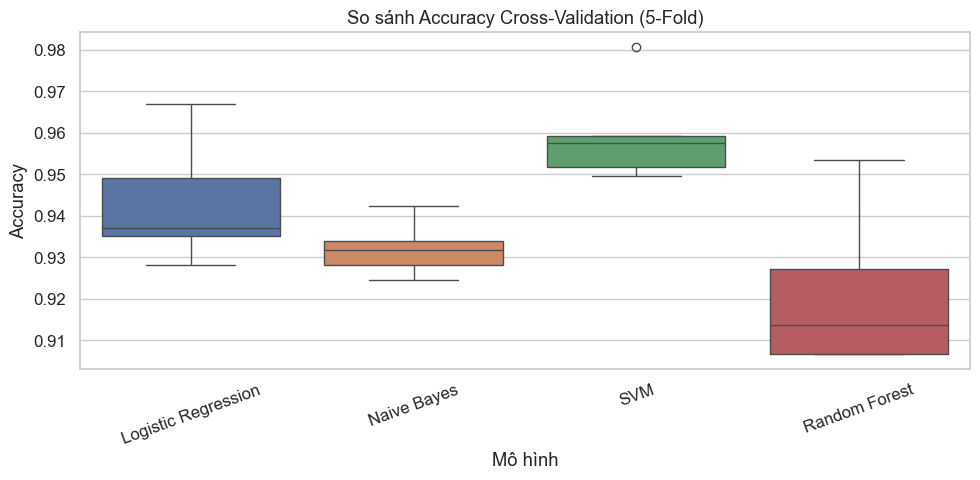

In [14]:
show_title("KẾT QUẢ CELL 12: SO SÁNH NHIỀU MÔ HÌNH")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC(max_iter=2000, class_weight='balanced', random_state=42, dual=False),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

min_class_after_smote = pd.Series(y_train_smote).value_counts().min()
cv_folds = min(5, int(min_class_after_smote))
if cv_folds < 2:
    raise ValueError("Không đủ mẫu mỗi lớp để chạy cross-validation.")

cv_results = {}
cv_summary_rows = []

for name, model in models.items():
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv_folds, scoring='accuracy')
    cv_results[name] = scores
    cv_summary_rows.append({
        "Mô hình": name,
        "Accuracy trung bình": scores.mean(),
        "Độ lệch chuẩn": scores.std(),
        "Accuracy thấp nhất": scores.min(),
        "Accuracy cao nhất": scores.max()
    })

cv_summary = pd.DataFrame(cv_summary_rows).sort_values("Accuracy trung bình", ascending=False)
display_df(f"Kết quả Cross-Validation ({cv_folds}-Fold):", cv_summary, max_rows=10)

df_cv = pd.DataFrame(cv_results)
display_df("Điểm accuracy từng fold dùng để vẽ biểu đồ:", df_cv, max_rows=10)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_cv)
plt.title(f'So sánh Accuracy Cross-Validation ({cv_folds}-Fold)')
plt.ylabel('Accuracy')
plt.xlabel('Mô hình')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 13. Hyperparameter Tuning (GridSearchCV)

In [15]:
show_title("KẾT QUẢ CELL 13: TỐI ƯU HYPERPARAMETER BẰNG GRIDSEARCHCV")

param_grid = {
    'C': [0.1, 1, 10],
    'max_iter': [500, 1000, 2000],
    'solver': ['liblinear', 'saga']
}

min_class_after_smote = pd.Series(y_train_smote).value_counts().min()
cv_folds = min(5, int(min_class_after_smote))

grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid, cv=cv_folds, scoring='accuracy', n_jobs=-1, verbose=1
)

print('Đang tuning Logistic Regression...')
grid_search.fit(X_train_smote, y_train_smote)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

grid_results = pd.DataFrame(grid_search.cv_results_)
top_grid = grid_results.sort_values("rank_test_score").head(10)[[
    "rank_test_score", "mean_test_score", "std_test_score", "param_C", "param_max_iter", "param_solver"
]]
display_df("Top 10 tổ hợp tham số tốt nhất:", top_grid, max_rows=10)

tuning_summary = pd.DataFrame({
    "Chỉ số": ["Best parameters", "Best CV score", "Test Accuracy"],
    "Giá trị": [str(grid_search.best_params_), f"{grid_search.best_score_:.4f}", f"{accuracy_score(y_test, y_pred_tuned):.4f}"]
})
display_df("Tóm tắt kết quả tuning:", tuning_summary, max_rows=10)


KẾT QUẢ CELL 13: TỐI ƯU HYPERPARAMETER BẰNG GRIDSEARCHCV
Đang tuning Logistic Regression...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Top 10 tổ hợp tham số tốt nhất:


,rank_test_score,mean_test_score,std_test_score,param_C,param_max_iter,param_solver
13,1,0.958089,0.011250,10.0,500,saga
15,1,0.958089,0.011250,10.0,1000,saga
17,1,0.958089,0.011250,10.0,2000,saga
12,4,0.957879,0.011287,10.0,500,liblinear
16,4,0.957879,0.011287,10.0,2000,liblinear
14,4,0.957879,0.011287,10.0,1000,liblinear
7,7,0.943001,0.013664,1.0,500,saga
11,7,0.943001,0.013664,1.0,2000,saga
9,7,0.943001,0.013664,1.0,1000,saga
8,10,0.942897,0.013782,1.0,1000,liblinear



Tóm tắt kết quả tuning:


,Chỉ số,Giá trị
0,Best parameters,"{'C': 10, 'max_iter': 500, 'solver': 'saga'}"
1,Best CV score,0.9581
2,Test Accuracy,0.9417


## 14. Đánh giá mô hình (Model Evaluation)


KẾT QUẢ CELL 14: ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT
Accuracy trên tập test: 0.9417
Thứ tự nhãn của mô hình: ['negative', 'positive']

Classification report dạng bảng:


,precision,recall,f1-score,support
negative,0.958439,0.947192,0.952782,1193.000000
positive,0.914980,0.932600,0.923706,727.000000
accuracy,0.941667,0.941667,0.941667,0.941667
macro avg,0.936710,0.939896,0.938244,1920.000000
weighted avg,0.941984,0.941667,0.941773,1920.000000



Ma trận nhầm lẫn dạng bảng:


,Dự đoán: negative,Dự đoán: positive
Thực tế: negative,1130,63
Thực tế: positive,49,678


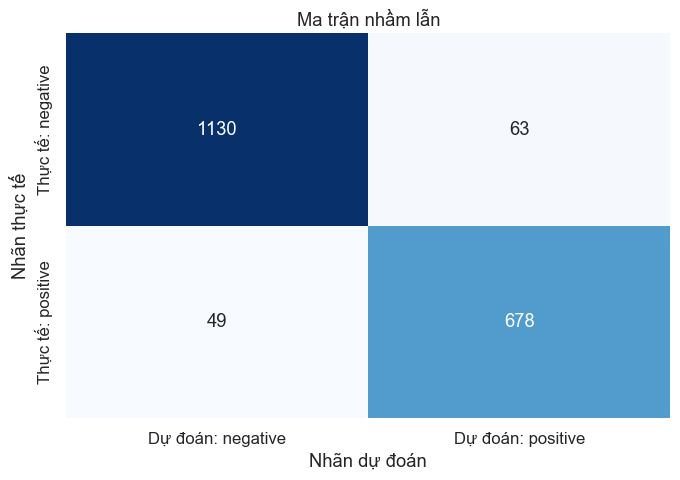

In [16]:
show_title("KẾT QUẢ CELL 14: ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT")

model_labels = list(best_model.classes_)
accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Accuracy trên tập test: {accuracy:.4f}")
print(f"Thứ tự nhãn của mô hình: {model_labels}")

report_dict = classification_report(y_test, y_pred_tuned, labels=model_labels, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
display_df("Classification report dạng bảng:", report_df, max_rows=20)

cm = confusion_matrix(y_test, y_pred_tuned, labels=model_labels)
cm_df = pd.DataFrame(cm, index=[f"Thực tế: {x}" for x in model_labels], columns=[f"Dự đoán: {x}" for x in model_labels])
display_df("Ma trận nhầm lẫn dạng bảng:", cm_df, max_rows=20)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Ma trận nhầm lẫn')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()
plt.show()

## 15. ROC-AUC & Precision-Recall Curves


KẾT QUẢ CELL 15: ROC-AUC VÀ PRECISION-RECALL
Thứ tự cột xác suất theo best_model.classes_: ['negative', 'positive']

5 dòng xác suất dự đoán đầu tiên:


,negative,positive
0,0.002568,0.997432
1,0.996878,0.003122
2,0.005113,0.994887
3,0.864084,0.135916
4,0.992201,0.007799



Bảng kiểm tra dữ liệu dùng cho ROC/Precision-Recall:


,Nhãn đánh giá,ROC-AUC,Số mẫu positive trong test,Số mẫu còn lại
0,positive,0.979476,727,1193


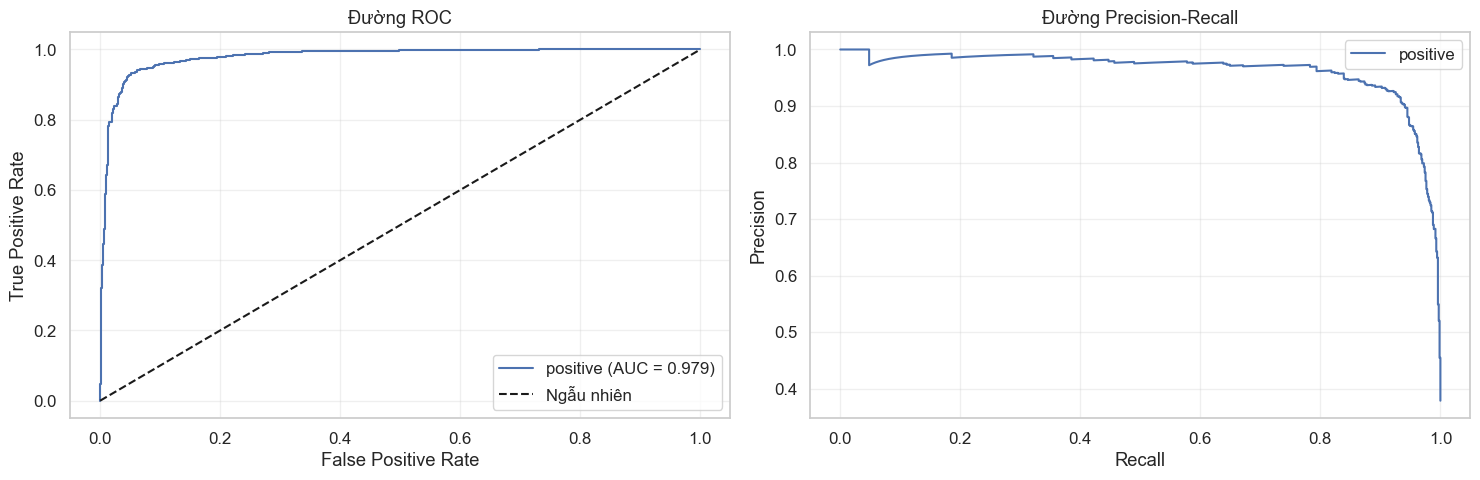

In [17]:
show_title("KẾT QUẢ CELL 15: ROC-AUC VÀ PRECISION-RECALL")

model_labels = list(best_model.classes_)
y_pred_proba = best_model.predict_proba(X_test)

print(f"Thứ tự cột xác suất theo best_model.classes_: {model_labels}")
display_df("5 dòng xác suất dự đoán đầu tiên:", pd.DataFrame(y_pred_proba[:5], columns=model_labels), max_rows=5)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
curve_rows = []

if len(model_labels) == 2:
    positive_class = 'positive' if 'positive' in model_labels else model_labels[1]
    positive_class_index = model_labels.index(positive_class)
    y_true_binary = (y_test == positive_class).astype(int).values
    y_score = y_pred_proba[:, positive_class_index]

    fpr, tpr, _ = roc_curve(y_true_binary, y_score)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)

    axes[0].plot(fpr, tpr, label=f'{positive_class} (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên')
    axes[1].plot(recall, precision, label=positive_class)

    curve_rows.append({
        "Nhãn đánh giá": positive_class,
        "ROC-AUC": roc_auc_score(y_true_binary, y_score),
        "Số mẫu positive trong test": int(y_true_binary.sum()),
        "Số mẫu còn lại": int((1 - y_true_binary).sum())
    })

else:
    y_test_bin = label_binarize(y_test, classes=model_labels)

    for i, label in enumerate(model_labels):
        y_true_binary = y_test_bin[:, i]
        y_score = y_pred_proba[:, i]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)

        axes[0].plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})')
        axes[1].plot(recall, precision, label=label)

        curve_rows.append({
            "Nhãn đánh giá": label,
            "ROC-AUC": roc_auc,
            "Số mẫu positive trong test": int(y_true_binary.sum()),
            "Số mẫu còn lại": int((1 - y_true_binary).sum())
        })

    axes[0].plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên')

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_title('Đường ROC')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')

axes[1].set_title('Đường Precision-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')

curve_summary = pd.DataFrame(curve_rows)
display_df("Bảng kiểm tra dữ liệu dùng cho ROC/Precision-Recall:", curve_summary, max_rows=20)

plt.tight_layout()
plt.show()

## 16. Trực quan hóa Feature Importance


KẾT QUẢ CELL 16: TRỰC QUAN HÓA FEATURE IMPORTANCE

Bảng top feature importance dùng để vẽ biểu đồ:


,Nhãn,Từ/cụm từ,Hệ số
0,negative,nhưng,9.135753
1,negative,tệ,7.720643
2,negative,móp,6.692171
3,negative,kém,6.362624
4,negative,chán,5.971663
5,negative,ra,5.964489
6,negative,không_được,5.780601
7,negative,thiếu,5.585829
8,negative,tặng,5.337081
9,negative,ngứa,4.552818


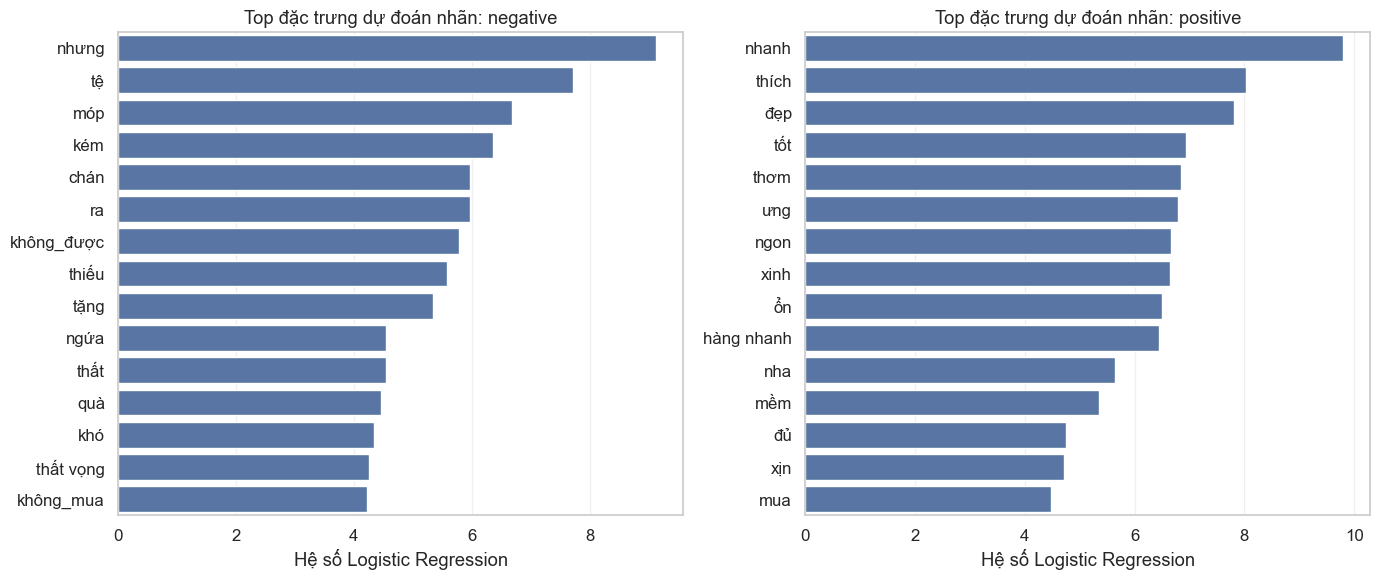

In [18]:
show_title("KẾT QUẢ CELL 16: TRỰC QUAN HÓA FEATURE IMPORTANCE")

feature_names = vectorizer.get_feature_names_out()
model_labels = list(best_model.classes_)

if hasattr(best_model, 'coef_'):
    coefs = best_model.coef_

    if len(model_labels) == 2 and coefs.shape[0] == 1:
        coef_map = {
            model_labels[0]: -coefs[0],
            model_labels[1]: coefs[0]
        }
    else:
        coef_map = {label: coefs[idx] for idx, label in enumerate(model_labels)}

    importance_tables = []
    fig, axes = plt.subplots(1, len(model_labels), figsize=(7 * len(model_labels), 6))
    axes = np.ravel([axes]) if len(model_labels) == 1 else np.ravel(axes)

    for ax, label in zip(axes, model_labels):
        coef_values = coef_map[label]
        top_idx = np.argsort(coef_values)[-15:][::-1]
        top_features = [feature_names[j] for j in top_idx]
        top_values = coef_values[top_idx]

        importance_df = pd.DataFrame({
            "Nhãn": label,
            "Từ/cụm từ": top_features,
            "Hệ số": top_values
        })
        importance_tables.append(importance_df)

        sns.barplot(data=importance_df, x="Hệ số", y="Từ/cụm từ", ax=ax)
        ax.set_xlabel('Hệ số Logistic Regression')
        ax.set_ylabel('')
        ax.set_title(f'Top đặc trưng dự đoán nhãn: {label}')
        ax.grid(True, alpha=0.3, axis='x')

    all_importance_df = pd.concat(importance_tables, ignore_index=True)
    display_df("Bảng top feature importance dùng để vẽ biểu đồ:", all_importance_df, max_rows=50)

    plt.tight_layout()
    plt.show()
else:
    print('Bỏ qua feature importance: best_model không có thuộc tính coef_.')

## 17. Phân tích lỗi (Error Analysis)

In [19]:
show_title("KẾT QUẢ CELL 17: PHÂN TÍCH LỖI")

error_mask = y_pred_tuned != y_test
error_count = int(error_mask.sum())

error_summary = pd.DataFrame({
    "Chỉ số": ["Tổng số mẫu test", "Số mẫu dự đoán sai", "Tỷ lệ lỗi"],
    "Giá trị": [len(y_test), error_count, f"{error_count / len(y_test) * 100:.2f}%"]
})
display_df("Tóm tắt lỗi dự đoán:", error_summary, max_rows=10)

misclass_rows = []
for true_label in model_labels:
    for pred_label in model_labels:
        if true_label != pred_label:
            count = int(((y_test == true_label) & (y_pred_tuned == pred_label)).sum())
            if count > 0:
                misclass_rows.append({"Nhãn thật": true_label, "Nhãn dự đoán": pred_label, "Số lượng": count})

misclass_df = pd.DataFrame(misclass_rows)
if len(misclass_df) > 0:
    display_df("Bảng các kiểu nhầm lẫn:", misclass_df, max_rows=20)
else:
    print("Không có mẫu nào bị dự đoán sai.")

per_class_rows = []
for label in model_labels:
    y_true_binary = (y_test == label).astype(int)
    y_pred_binary = (y_pred_tuned == label).astype(int)
    per_class_rows.append({
        "Nhãn": label,
        "Precision": precision_score(y_true_binary, y_pred_binary, zero_division=0),
        "Recall": recall_score(y_true_binary, y_pred_binary, zero_division=0),
        "F1-score": f1_score(y_true_binary, y_pred_binary, zero_division=0)
    })

per_class_df = pd.DataFrame(per_class_rows)
display_df("Chỉ số theo từng nhãn:", per_class_df, max_rows=20)

error_examples = pd.DataFrame({
    "review": X_test_text.values,
    "y_true": y_test.values,
    "y_pred": y_pred_tuned
})
error_examples = error_examples[error_examples["y_true"] != error_examples["y_pred"]].head(10)
if len(error_examples) > 0:
    display_df("10 ví dụ dự đoán sai đầu tiên:", error_examples, max_rows=10)


KẾT QUẢ CELL 17: PHÂN TÍCH LỖI

Tóm tắt lỗi dự đoán:


,Chỉ số,Giá trị
0,Tổng số mẫu test,1920
1,Số mẫu dự đoán sai,112
2,Tỷ lệ lỗi,5.83%



Bảng các kiểu nhầm lẫn:


,Nhãn thật,Nhãn dự đoán,Số lượng
0,negative,positive,63
1,positive,negative,49



Chỉ số theo từng nhãn:


,Nhãn,Precision,Recall,F1-score
0,negative,0.958439,0.947192,0.952782
1,positive,0.914980,0.932600,0.923706



10 ví dụ dự đoán sai đầu tiên:


,review,y_true,y_pred
50,độ tuổi sử dụng trên tuổi chất lượng sản phẩm ...,negative,positive
75,chống lão hóa không_giá chát dùng đến chai thứ...,negative,positive
88,thấy ny bảo mỏng mùi dễ chịu nma quên không_th...,positive,negative
94,xanh ngọc ngon nhất nha mọi người may mau hôi ...,negative,positive
123,hình k phải chính hãng xả xong tóc khô quá k b...,negative,positive
132,dành da dảy da trâu may ra xài được công dụng ...,negative,positive
138,nhận được hàng đóng gói cẩn thận chỉn chu gửi ...,positive,negative
172,kinh nghiệm sử dụng dùng xả trước lợi ích làm ...,positive,negative
176,dưỡng ẩm moi dùng lần chưa_biết làm sáng da th...,negative,positive
187,kinh nghiệm sử dụng lần đầu sd so sd nhìu loại...,negative,positive


## 18. Model Calibration


KẾT QUẢ CELL 18: MODEL CALIBRATION

So sánh accuracy trước/sau calibration (cv=5):


,Mô hình,Accuracy
0,Original best_model,0.941667
1,Calibrated model,0.938542



5 dòng xác suất calibrated đầu tiên:


,negative,positive
0,0.000363,0.999637
1,0.999214,0.000786
2,0.000928,0.999072
3,0.920680,0.079320
4,0.998444,0.001556



Dữ liệu dùng để vẽ calibration curve:


,Nhãn,Mean predicted probability,Fraction of positives
0,negative,0.015418,0.027027
1,negative,0.142732,0.148148
2,negative,0.248710,0.277778
3,negative,0.354183,0.307692
4,negative,0.454543,0.222222
5,negative,0.533823,0.424242
6,negative,0.650805,0.703704
7,negative,0.753301,0.767442
8,negative,0.852535,0.858974
9,negative,0.989476,0.979651


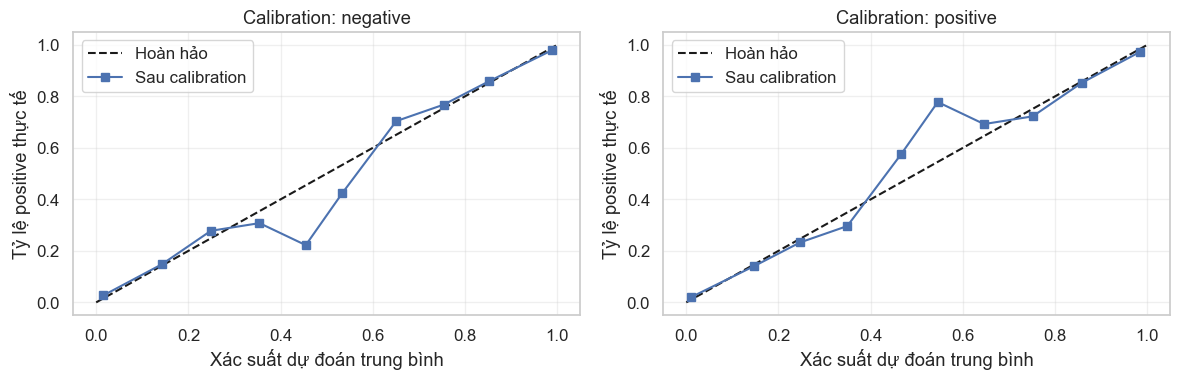

In [20]:
show_title("KẾT QUẢ CELL 18: MODEL CALIBRATION")

min_class_after_smote = pd.Series(y_train_smote).value_counts().min()
calibration_cv = min(5, int(min_class_after_smote))

calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=calibration_cv)
calibrated_model.fit(X_train_smote, y_train_smote)

y_proba_calibrated = calibrated_model.predict_proba(X_test)
y_pred_calibrated = calibrated_model.predict(X_test)
model_labels = list(calibrated_model.classes_)

calibration_summary = pd.DataFrame({
    "Mô hình": ["Original best_model", "Calibrated model"],
    "Accuracy": [accuracy_score(y_test, y_pred_tuned), accuracy_score(y_test, y_pred_calibrated)]
})
display_df(f"So sánh accuracy trước/sau calibration (cv={calibration_cv}):", calibration_summary, max_rows=10)

display_df("5 dòng xác suất calibrated đầu tiên:", pd.DataFrame(y_proba_calibrated[:5], columns=model_labels), max_rows=5)

fig, axes = plt.subplots(1, len(model_labels), figsize=(6 * len(model_labels), 4))
axes = np.ravel([axes]) if len(model_labels) == 1 else np.ravel(axes)

calibration_rows = []
for i, label in enumerate(model_labels):
    y_true_binary = (y_test == label).astype(int).values
    prob_true, prob_pred = calibration_curve(y_true_binary, y_proba_calibrated[:, i], n_bins=10)

    bin_df = pd.DataFrame({
        "Nhãn": label,
        "Mean predicted probability": prob_pred,
        "Fraction of positives": prob_true
    })
    calibration_rows.append(bin_df)

    axes[i].plot([0, 1], [0, 1], 'k--', label='Hoàn hảo')
    axes[i].plot(prob_pred, prob_true, 's-', label='Sau calibration')
    axes[i].set_xlabel('Xác suất dự đoán trung bình')
    axes[i].set_ylabel('Tỷ lệ positive thực tế')
    axes[i].set_title(f'Calibration: {label}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

calibration_df = pd.concat(calibration_rows, ignore_index=True)
display_df("Dữ liệu dùng để vẽ calibration curve:", calibration_df, max_rows=50)

plt.tight_layout()
plt.show()

---
## PHẦN III: KỸ THUẬT NLP NÂNG CAO
---

## 19. Named Entity Recognition (NER)

In [21]:
show_title("KẾT QUẢ CELL 19: NHẬN DIỆN THỰC THỂ ĐƠN GIẢN")

product_patterns = {
    'phone': r'\b(điện thoại|phone|dth|iphone|samsung|oppo|realme|xiaomi|nokia)\b',
    'laptop': r'\b(laptop|macbook|asus|dell|hp|lenovo|acer|toshiba)\b',
    'clothing': r'\b(áo|quần|giày|dép|túi|váy|thời trang)\b',
    'food': r'\b(thực phẩm|đồ ăn|bánh|kẹo|trà|cà phê)\b',
    'cosmetic': r'\b(mỹ phẩm|toner|serum|mặt nạ|kem dưỡng)\b'
}

def extract_entities(text):
    entities = defaultdict(list)
    text_lower = text.lower()
    for entity_type, pattern in product_patterns.items():
        matches = re.findall(pattern, text_lower)
        if matches:
            entities[f'product_{entity_type}'] = sorted(list(set(matches)))
    return dict(entities)

df_clean['entities'] = df_clean['review'].apply(extract_entities)

entity_rows = []
sentiment_order = [lbl for lbl in ['positive', 'neutral', 'negative'] if lbl in df_clean['label'].unique()]
for sentiment in sentiment_order:
    all_entities = []
    for entities_dict in df_clean[df_clean['label'] == sentiment]['entities']:
        for values in entities_dict.values():
            all_entities.extend(values)
    for entity, count in Counter(all_entities).most_common(10):
        entity_rows.append({"Nhãn": sentiment, "Thực thể": entity, "Số lần xuất hiện": count})

entity_df = pd.DataFrame(entity_rows)
if len(entity_df) > 0:
    display_df("Top thực thể theo từng nhãn:", entity_df, max_rows=50)
else:
    print("Không tìm thấy thực thể nào theo bộ pattern hiện tại.")

display_df("Ví dụ review và thực thể trích xuất:", df_clean[['review', 'label', 'entities']].head(10), max_rows=10)


KẾT QUẢ CELL 19: NHẬN DIỆN THỰC THỂ ĐƠN GIẢN

Top thực thể theo từng nhãn:


,Nhãn,Thực thể,Số lần xuất hiện
0,positive,túi,39
1,positive,quần,34
2,positive,serum,31
3,positive,dép,31
4,positive,mặt nạ,22
5,positive,cà phê,21
6,positive,kem dưỡng,18
7,positive,áo,17
8,positive,bánh,7
9,positive,kẹo,6



Ví dụ review và thực thể trích xuất:


,review,label,entities
0,Hương vị:thom Chắc do bên giao hàng bị vỡ mấy...,negative,{}
1,Hương thơm:nhẹ nhàng Lợi ích:phục hồi cấp ẩm M...,positive,{}
2,Chất lượng sản phẩm:ok Đúng với mô tả:đúng Lầ...,positive,{}
3,Độ tuổi sử dụng:em bes Chất lượng sản phẩm:tot...,positive,{}
4,"Hương vị:Mix vị, Tím Mình mua 64 gói (32 gói ...",negative,{}
5,Hàng đặt sữa uống mà giao hàng 15 ngày,negative,{}
6,Màu sắc:Black & Grey Đúng với mô tả:100% Chất ...,positive,{}
7,"Gói cẩu thả, móp méo",negative,{}
8,Chất lượng sản phẩm:thấy mọi người rư nhiều nê...,negative,{}
9,Mua máy về chưa dc 1 tháng mà sấy lúc lên lúc ...,negative,{}


## 20. Sentiment Lexicon Analysis

In [22]:
show_title("KẾT QUẢ CELL 20: PHÂN TÍCH SENTIMENT LEXICON")

positive_words = {
    'tốt', 'rất tốt', 'xuất sắc', 'tuyệt vời', 'hoàn hảo', 'hài lòng',
    'thích', 'yêu', 'hay', 'ok', 'ổn', 'chất lượng', 'đẹp', 'nhanh'
}

negative_words = {
    'xấu', 'rất xấu', 'tệ', 'khủng khiếp', 'thất vọng', 'không hài lòng',
    'ghét', 'lỗi', 'hỏng', 'kém', 'bẩn', 'chậm', 'hư', 'lừa'
}

def score_sentiment_lexicon(text):
    text_lower = text.lower()
    tokens = text_lower.split()
    pos_count = sum(1 for word in tokens if word in positive_words)
    neg_count = sum(1 for word in tokens if word in negative_words)
    return {'positive': pos_count, 'negative': neg_count, 'score': pos_count - neg_count}

df_clean['lexicon_score'] = df_clean['review_clean'].apply(score_sentiment_lexicon)
df_clean['lexicon_pos'] = df_clean['lexicon_score'].apply(lambda x: x['positive'])
df_clean['lexicon_neg'] = df_clean['lexicon_score'].apply(lambda x: x['negative'])
df_clean['lexicon_total_score'] = df_clean['lexicon_score'].apply(lambda x: x['score'])

lexicon_summary = df_clean.groupby('label')[['lexicon_pos', 'lexicon_neg', 'lexicon_total_score']].agg(['mean', 'sum'])
display_df("Tóm tắt điểm lexicon theo nhãn:", lexicon_summary, max_rows=20)

sample_lexicon = df_clean[['review', 'label', 'lexicon_score']].head(10)
display_df("10 ví dụ điểm lexicon:", sample_lexicon, max_rows=10)


KẾT QUẢ CELL 20: PHÂN TÍCH SENTIMENT LEXICON

Tóm tắt điểm lexicon theo nhãn:


lexicon_pos       lexicon_neg       lexicon_total_score      
                mean   sum        mean   sum                mean   sum
label                                                                 
negative    0.395809  2361    0.278122  1659            0.117687   702
positive    1.317832  4789    0.013759    50            1.304073  4739


10 ví dụ điểm lexicon:


,review,label,lexicon_score
0,Hương vị:thom Chắc do bên giao hàng bị vỡ mấy...,negative,"{'positive': 0, 'negative': 0, 'score': 0}"
1,Hương thơm:nhẹ nhàng Lợi ích:phục hồi cấp ẩm M...,positive,"{'positive': 1, 'negative': 0, 'score': 1}"
2,Chất lượng sản phẩm:ok Đúng với mô tả:đúng Lầ...,positive,"{'positive': 1, 'negative': 0, 'score': 1}"
3,Độ tuổi sử dụng:em bes Chất lượng sản phẩm:tot...,positive,"{'positive': 0, 'negative': 0, 'score': 0}"
4,"Hương vị:Mix vị, Tím Mình mua 64 gói (32 gói ...",negative,"{'positive': 0, 'negative': 0, 'score': 0}"
5,Hàng đặt sữa uống mà giao hàng 15 ngày,negative,"{'positive': 0, 'negative': 0, 'score': 0}"
6,Màu sắc:Black & Grey Đúng với mô tả:100% Chất ...,positive,"{'positive': 1, 'negative': 0, 'score': 1}"
7,"Gói cẩu thả, móp méo",negative,"{'positive': 0, 'negative': 0, 'score': 0}"
8,Chất lượng sản phẩm:thấy mọi người rư nhiều nê...,negative,"{'positive': 0, 'negative': 0, 'score': 0}"
9,Mua máy về chưa dc 1 tháng mà sấy lúc lên lúc ...,negative,"{'positive': 0, 'negative': 0, 'score': 0}"


## 21. Aspect-Based Sentiment Analysis (ABSA)


KẾT QUẢ CELL 21: ASPECT-BASED SENTIMENT ANALYSIS

Bảng phân bố cảm xúc theo từng khía cạnh:


,Khía cạnh,positive,negative
0,quality,2396,3554
1,price,940,723
2,delivery,1543,970
3,service,759,558
4,appearance,881,839



Dữ liệu dạng long dùng để vẽ biểu đồ ABSA:


,Khía cạnh,Nhãn cảm xúc,Số lượng
0,quality,positive,2396
1,price,positive,940
2,delivery,positive,1543
3,service,positive,759
4,appearance,positive,881
5,quality,negative,3554
6,price,negative,723
7,delivery,negative,970
8,service,negative,558
9,appearance,negative,839


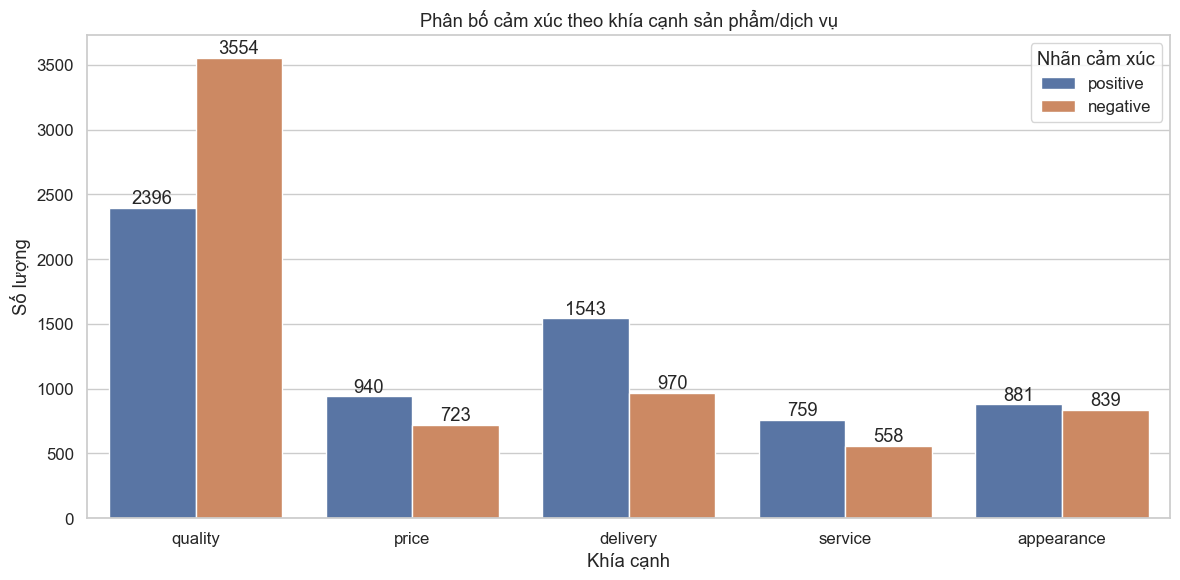

In [23]:
show_title("KẾT QUẢ CELL 21: ASPECT-BASED SENTIMENT ANALYSIS")

aspects = {
    'quality': ['chất lượng', 'chất', 'tốt', 'xấu', 'hư', 'vỡ'],
    'price': ['giá', 'đắt', 'rẻ', 'mắc', 'hợp lý'],
    'delivery': ['giao hàng', 'ship', 'nhanh', 'chậm', 'hư hỏng'],
    'service': ['dịch vụ', 'hỗ trợ', 'phục vụ', 'tốt', 'kém'],
    'appearance': ['đẹp', 'xấu', 'màu', 'kiểu', 'bắt mắt']
}

sentiment_order = [lbl for lbl in ['positive', 'neutral', 'negative'] if lbl in df_clean['label'].unique()]
aspect_sentiment = {aspect: {sentiment: 0 for sentiment in sentiment_order} for aspect in aspects}

def extract_aspects(text, label):
    text_lower = text.lower()
    for aspect, keywords in aspects.items():
        if any(keyword in text_lower for keyword in keywords):
            aspect_sentiment[aspect][label] += 1

for text, label in zip(df_clean['review_clean'], df_clean['label']):
    extract_aspects(text, label)

aspect_df = pd.DataFrame(aspect_sentiment).T[sentiment_order]
aspect_df.index.name = "Khía cạnh"
display_df("Bảng phân bố cảm xúc theo từng khía cạnh:", aspect_df.reset_index(), max_rows=20)

aspect_plot_df = aspect_df.reset_index().melt(id_vars="Khía cạnh", var_name="Nhãn cảm xúc", value_name="Số lượng")
display_df("Dữ liệu dạng long dùng để vẽ biểu đồ ABSA:", aspect_plot_df, max_rows=50)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=aspect_plot_df, x="Khía cạnh", y="Số lượng", hue="Nhãn cảm xúc", ax=ax)
ax.set_ylabel('Số lượng')
ax.set_xlabel('Khía cạnh')
ax.set_title('Phân bố cảm xúc theo khía cạnh sản phẩm/dịch vụ')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.tight_layout()
plt.show()

## 22. Model Stacking

In [24]:
show_title("KẾT QUẢ CELL 22: MODEL STACKING")

base_learners = [
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('nb', MultinomialNB()),
    ('svm', CalibratedClassifierCV(
        LinearSVC(max_iter=2000, class_weight='balanced', random_state=42, dual=False),
        method='sigmoid',
        cv=3
    ))
]

meta_features_train = np.zeros((X_train_smote.shape[0], len(base_learners)))
meta_features_test = np.zeros((X_test.shape[0], len(base_learners)))

target_class = 'positive' if 'positive' in pd.Series(y_train_smote).unique() else sorted(pd.Series(y_train_smote).unique())[-1]
print(f"Class mục tiêu để lấy xác suất stacking: {target_class}")

min_class_after_smote = pd.Series(y_train_smote).value_counts().min()
stacking_cv = min(5, int(min_class_after_smote))

base_rows = []
for i, (name, model) in enumerate(base_learners):
    proba_cv = cross_val_predict(model, X_train_smote, y_train_smote, cv=stacking_cv, method='predict_proba')
    fitted_model = clone(model).fit(X_train_smote, y_train_smote)

    class_index = list(fitted_model.classes_).index(target_class)
    meta_features_train[:, i] = proba_cv[:, class_index]
    meta_features_test[:, i] = fitted_model.predict_proba(X_test)[:, class_index]

    base_pred = fitted_model.predict(X_test)
    base_rows.append({
        "Base learner": name,
        "Accuracy test": accuracy_score(y_test, base_pred),
        "Class dùng làm meta-feature": target_class
    })

base_df = pd.DataFrame(base_rows)
display_df("Kết quả từng base learner:", base_df, max_rows=10)

meta_learner = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
meta_learner.fit(meta_features_train, y_train_smote)
y_pred_stacked = meta_learner.predict(meta_features_test)

stacking_summary = pd.DataFrame({
    "Mô hình": ["Best single model", "Stacking model"],
    "Accuracy": [accuracy_score(y_test, y_pred_tuned), accuracy_score(y_test, y_pred_stacked)]
})
stacking_summary["Chênh lệch so với best single"] = stacking_summary["Accuracy"] - accuracy_score(y_test, y_pred_tuned)

display_df("So sánh stacking với mô hình đơn tốt nhất:", stacking_summary, max_rows=10)
display_df("5 dòng meta-features test đầu tiên:", pd.DataFrame(meta_features_test, columns=[name for name, _ in base_learners]).head(), max_rows=5)


KẾT QUẢ CELL 22: MODEL STACKING
Class mục tiêu để lấy xác suất stacking: positive

Kết quả từng base learner:


,Base learner,Accuracy test,Class dùng làm meta-feature
0,lr,0.925000,positive
1,nb,0.914583,positive
2,svm,0.938542,positive



So sánh stacking với mô hình đơn tốt nhất:


,Mô hình,Accuracy,Chênh lệch so với best single
0,Best single model,0.941667,0.000000
1,Stacking model,0.942187,0.000521



5 dòng meta-features test đầu tiên:


,lr,nb,svm
0,0.987384,0.997717,0.999751
1,0.047152,0.008234,0.000729
2,0.965973,0.992859,0.999128
3,0.321313,0.447340,0.078904
4,0.030595,0.024560,0.001845


## 23. Word2Vec & FastText Embeddings

In [ ]:
show_title("KẾT QUẢ CELL 23: WORD2VEC & FASTTEXT EMBEDDINGS")

if not GENSIM_AVAILABLE:
    print('Bỏ qua Word2Vec/FastText: Gensim không khả dụng trong môi trường hiện tại.')
    if 'GENSIM_ERROR' in globals():
        print(f"Lý do: {GENSIM_ERROR}")
else:
    tokenized_train = [text.split() for text in X_train_text]
    tokenized_test = [text.split() for text in X_test_text]

    token_summary = pd.DataFrame({
        "Tập": ["Train", "Test"],
        "Số câu": [len(tokenized_train), len(tokenized_test)],
        "Số token trung bình": [
            np.mean([len(x) for x in tokenized_train]) if tokenized_train else 0,
            np.mean([len(x) for x in tokenized_test]) if tokenized_test else 0
        ]
    })
    display_df("Tóm tắt dữ liệu token dùng train embedding:", token_summary, max_rows=10)

    print('Đang train Word2Vec model...')
    w2v_model = Word2Vec(sentences=tokenized_train, vector_size=100, window=5, min_count=2, workers=4, seed=42)
    print(f'Kích thước vocabulary Word2Vec: {len(w2v_model.wv)}')

    print('Đang train FastText model...')
    ft_model = FastText(sentences=tokenized_train, vector_size=100, window=5, min_count=2, workers=4, seed=42)
    print(f'Kích thước vocabulary FastText: {len(ft_model.wv)}')

    def get_sentence_embedding(tokens, model, vector_size=100):
        vectors = [model.wv[token] for token in tokens if token in model.wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

    X_train_w2v = np.array([get_sentence_embedding(tokens, w2v_model) for tokens in tokenized_train])
    X_test_w2v = np.array([get_sentence_embedding(tokens, w2v_model) for tokens in tokenized_test])

    X_train_ft = np.array([get_sentence_embedding(tokens, ft_model) for tokens in tokenized_train])
    X_test_ft = np.array([get_sentence_embedding(tokens, ft_model) for tokens in tokenized_test])

    embedding_shape_df = pd.DataFrame({
        "Embedding": ["Word2Vec train", "Word2Vec test", "FastText train", "FastText test"],
        "Shape": [str(X_train_w2v.shape), str(X_test_w2v.shape), str(X_train_ft.shape), str(X_test_ft.shape)]
    })
    display_df("Kích thước ma trận embedding:", embedding_shape_df, max_rows=10)

    lr_w2v = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr_w2v.fit(X_train_w2v, y_train)
    acc_w2v = accuracy_score(y_test, lr_w2v.predict(X_test_w2v))

    lr_ft = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr_ft.fit(X_train_ft, y_train)
    acc_ft = accuracy_score(y_test, lr_ft.predict(X_test_ft))

    embedding_result_df = pd.DataFrame({
        "Mô hình": ["TF-IDF + LogReg", "Word2Vec + LogReg", "FastText + LogReg"],
        "Accuracy test": [accuracy_score(y_test, y_pred_tuned), acc_w2v, acc_ft]
    }).sort_values("Accuracy test", ascending=False)
    display_df("So sánh mô hình dùng embedding:", embedding_result_df, max_rows=10)

    similar_rows = []
    for word in ['tốt', 'xấu', 'giao', 'hàng']:
        if word in w2v_model.wv:
            for sim_word, score in w2v_model.wv.most_similar(word, topn=5):
                similar_rows.append({"Từ gốc": word, "Từ gần nghĩa": sim_word, "Độ tương đồng": score})
    if similar_rows:
        display_df("Các từ gần nhất trong Word2Vec:", pd.DataFrame(similar_rows), max_rows=30)
    else:
        print("Không có từ mẫu nào xuất hiện trong vocabulary Word2Vec.")

## 24. Transformers - PhoBERT Analysis

In [25]:
show_title("KẾT QUẢ CELL 24: TRANSFORMERS - PHOBERT ANALYSIS")

try:
    from transformers import pipeline

    print('Đang tải PhoBERT pre-trained model...')
    sentiment_pipeline = pipeline("sentiment-analysis", model="wonrax/phobert-base-vietnamese-sentiment")

    sample_df = df_clean[['review_preprocessed', 'label']].sample(min(5, len(df_clean)), random_state=42).reset_index(drop=True)

    phobert_rows = []
    for _, row in sample_df.iterrows():
        review = row['review_preprocessed']
        true_label = row['label']
        result = sentiment_pipeline(review[:512])
        pred_label = result[0]['label']
        confidence = result[0]['score']
        phobert_rows.append({
            "Review rút gọn": review[:120],
            "Nhãn thật": true_label,
            "PhoBERT dự đoán": pred_label,
            "Độ tin cậy": confidence
        })

    phobert_df = pd.DataFrame(phobert_rows)
    display_df("Kết quả PhoBERT trên mẫu review:", phobert_df, max_rows=10)

except Exception as e:
    print(f'Bỏ qua PhoBERT analysis do lỗi/môi trường chưa hỗ trợ: {e}')


KẾT QUẢ CELL 24: TRANSFORMERS - PHOBERT ANALYSIS
Đang tải PhoBERT pre-trained model...


Device set to use cpu



Kết quả PhoBERT trên mẫu review:


,Review rút gọn,Nhãn thật,PhoBERT dự đoán,Độ tin cậy
0,giá rẻ không_hàng bổ đâu nha mọi người lộ rãnh...,negative,POS,0.825238
1,chưa_dùng nhưng hộp đẹp xịn đừng_chờ đợi gì ướ...,positive,POS,0.960156
2,mùi hương thom dành tóc khô xơ công dụng tạp n...,positive,POS,0.979811
3,siêu lành tính dịu nhẹ mọi làn da dưỡng ẩm tốt...,positive,POS,0.992451
4,da dầu nhưng dùng bản thấy bi khô da lắm í vừa...,negative,NEG,0.980772


---
## PHẦN IV: TÓM TẮT VÀ KẾT LUẬN
---

## 25. Tóm tắt các kỹ thuật NLP được sử dụng

In [26]:
show_title("KẾT QUẢ CELL 25: TÓM TẮT CÁC KỸ THUẬT NLP ĐÃ SỬ DỤNG")

summary = {
    "I. XỬ LÝ DỮ LIỆU (Data Processing)": [
        "Tải và kiểm tra chất lượng dữ liệu",
        "Làm sạch văn bản: URL, emoji, ký tự đặc biệt",
        "Chuẩn hóa viết tắt",
        "Tokenization tiếng Việt bằng underthesea/spaCy/fallback",
        "Xử lý stopwords và phủ định",
    ],
    "II. TRÍCH XUẤT THÔNG TIN (Information Extraction)": [
        "Named Entity Recognition đơn giản bằng pattern",
        "Sentiment Lexicon tiếng Việt",
        "Aspect-Based Sentiment Analysis",
        "Top keywords/feature importance theo nhãn",
    ],
    "III. BIỂU DIỄN VĂN BẢN (Text Representation)": [
        "TF-IDF unigram/bigram",
        "Word2Vec embeddings",
        "FastText embeddings",
        "Transformers/PhoBERT nếu môi trường hỗ trợ",
    ],
    "IV. PHÂN LOẠI CẢM XÚC (Sentiment Classification)": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM LinearSVC",
        "Random Forest",
        "Model Stacking",
    ],
    "V. ĐÁNH GIÁ VÀ TỐI ƯU (Evaluation & Optimization)": [
        "SMOTE xử lý lệch lớp",
        "Cross-validation",
        "GridSearchCV",
        "Confusion Matrix",
        "ROC-AUC và Precision-Recall",
        "Calibration curve",
        "Phân tích lỗi",
    ],
}

summary_rows = []
for category, techniques in summary.items():
    for technique in techniques:
        summary_rows.append({"Nhóm": category, "Kỹ thuật": technique})

summary_df = pd.DataFrame(summary_rows)
display_df("Bảng tóm tắt kỹ thuật đã sử dụng:", summary_df, max_rows=100)

tools = {
    "NLTK": "Tokenization, stopwords, NLP utilities",
    "spaCy": "Vietnamese NLP nếu có model vi_core_news_lg",
    "Transformers": "PhoBERT/pre-trained models",
    "Gensim": "Word2Vec, FastText embeddings",
    "scikit-learn": "ML models, metrics, optimization",
    "imbalanced-learn": "SMOTE xử lý mất cân bằng lớp",
    "Pandas & NumPy": "Xử lý bảng dữ liệu và tính toán",
    "Matplotlib & Seaborn": "Trực quan hóa dữ liệu",
}

tools_df = pd.DataFrame(list(tools.items()), columns=["Công cụ", "Vai trò"])
display_df("Công cụ Python được sử dụng:", tools_df, max_rows=20)

final_summary = pd.DataFrame({
    "Chỉ số cuối": [
        "Số mẫu sau làm sạch",
        "Số nhãn",
        "Các nhãn",
        "Số đặc trưng TF-IDF",
        "Accuracy best_model",
        "Accuracy stacking nếu đã chạy"
    ],
    "Giá trị": [
        len(df_clean),
        df_clean['label'].nunique(),
        ", ".join(sorted(df_clean['label'].unique())),
        X_train.shape[1],
        f"{accuracy_score(y_test, y_pred_tuned):.4f}" if 'y_pred_tuned' in globals() else "Chưa có",
        f"{accuracy_score(y_test, y_pred_stacked):.4f}" if 'y_pred_stacked' in globals() else "Chưa chạy"
    ]
})
display_df("Tổng kết kết quả cuối notebook:", final_summary, max_rows=20)
print("Notebook đã hoàn tất. Mỗi cell code đều có phần in/hiển thị dữ liệu để dễ theo dõi.")


KẾT QUẢ CELL 25: TÓM TẮT CÁC KỸ THUẬT NLP ĐÃ SỬ DỤNG

Bảng tóm tắt kỹ thuật đã sử dụng:


,Nhóm,Kỹ thuật
0,I. XỬ LÝ DỮ LIỆU (Data Processing),Tải và kiểm tra chất lượng dữ liệu
1,I. XỬ LÝ DỮ LIỆU (Data Processing),"Làm sạch văn bản: URL, emoji, ký tự đặc biệt"
2,I. XỬ LÝ DỮ LIỆU (Data Processing),Chuẩn hóa viết tắt
3,I. XỬ LÝ DỮ LIỆU (Data Processing),Tokenization tiếng Việt bằng underthesea/spaCy...
4,I. XỬ LÝ DỮ LIỆU (Data Processing),Xử lý stopwords và phủ định
5,II. TRÍCH XUẤT THÔNG TIN (Information Extraction),Named Entity Recognition đơn giản bằng pattern
6,II. TRÍCH XUẤT THÔNG TIN (Information Extraction),Sentiment Lexicon tiếng Việt
7,II. TRÍCH XUẤT THÔNG TIN (Information Extraction),Aspect-Based Sentiment Analysis
8,II. TRÍCH XUẤT THÔNG TIN (Information Extraction),Top keywords/feature importance theo nhãn
9,III. BIỂU DIỄN VĂN BẢN (Text Representation),TF-IDF unigram/bigram



Công cụ Python được sử dụng:


,Công cụ,Vai trò
0,NLTK,"Tokenization, stopwords, NLP utilities"
1,spaCy,Vietnamese NLP nếu có model vi_core_news_lg
2,Transformers,PhoBERT/pre-trained models
3,Gensim,"Word2Vec, FastText embeddings"
4,scikit-learn,"ML models, metrics, optimization"
5,imbalanced-learn,SMOTE xử lý mất cân bằng lớp
6,Pandas & NumPy,Xử lý bảng dữ liệu và tính toán
7,Matplotlib & Seaborn,Trực quan hóa dữ liệu



Tổng kết kết quả cuối notebook:


,Chỉ số cuối,Giá trị
0,Số mẫu sau làm sạch,9599
1,Số nhãn,2
2,Các nhãn,"negative, positive"
3,Số đặc trưng TF-IDF,15000
4,Accuracy best_model,0.9417
5,Accuracy stacking nếu đã chạy,0.9422


Notebook đã hoàn tất. Mỗi cell code đều có phần in/hiển thị dữ liệu để dễ theo dõi.
